# Comparative Study of Deep Learning Models for Facial Landmark Detection in Plastic Surgery Analysis

Kelompok 6

---

### Data Preprocessing

Import Libraries

In [ ]:
!pip install Optuna

In [ ]:
import os
import cv2
import zipfile
from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from sklearn.model_selection import train_test_split

import math
import gc
import optuna

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

Data Reading

In [ ]:
drive.mount('/content/drive')
zip_path = "/content/drive/MyDrive/Colab Notebooks/Datasets/ibug_300W_large_face_landmark_dataset.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall("/content/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_PATH = "ibug_300W_large_face_landmark_dataset"
XML_FILE = os.path.join(DATASET_PATH, "labels_ibug_300W.xml")

TARGET_SIZE = 256
BATCH_SIZE = 16
NUM_EPOCHS = 20
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
print(os.path.exists(XML_FILE))

True


In [ ]:
#Read metadata
tree = ET.parse(XML_FILE)
root = tree.getroot()

data = []

for image_tag in root.iter("image"):
    image_file = image_tag.get("file")
    image_path = os.path.join(DATASET_PATH, image_file)
    if not os.path.exists(image_path):
        continue
    box = image_tag.find("box")
    top = int(box.get("top"))
    left = int(box.get("left"))
    width = int(box.get("width"))
    height = int(box.get("height"))

    if width <= 0 or height <= 0:
        continue

    landmarks = []
    for part in box.iter("part"):
        landmark_id = int(part.get("name"))
        x = int(part.get("x"))
        y = int(part.get("y"))
        landmarks.append((x, y))

    if len(landmarks) != 68:
        continue

    landmarks = np.array(landmarks, dtype=np.float32)

    datas = {
        "image_path": image_path,
        "bbox": (left, top, width, height),
        "landmarks": landmarks
    }
    data.append(datas)

print("Total Images:", len(data))

Total Images: 7674


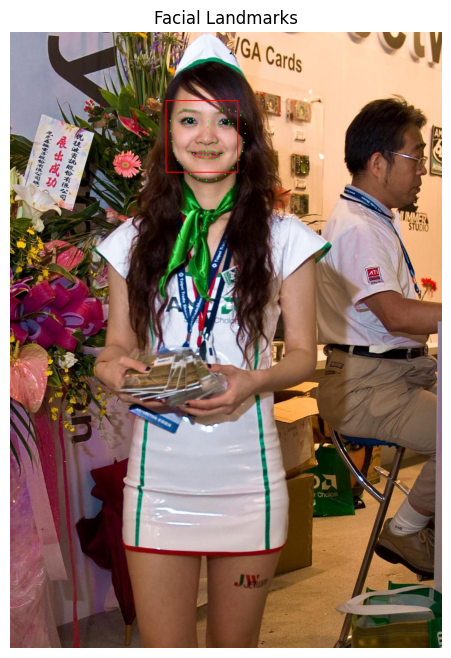

In [ ]:
#Testing landmarks
sample = data[0]
image = cv2.imread(sample["image_path"])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
landmarks = sample["landmarks"].astype(int)

for (x, y) in landmarks:
    cv2.circle(image,(x, y),2,(0, 255, 0),-1)

left, top, width, height = sample["bbox"]
cv2.rectangle(
    image,
    (int(left), int(top)),
    (int(left + width), int(top + height)),
    (255, 0, 0),
    2
)

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title("Facial Landmarks")
plt.axis("off")
plt.show()

In [ ]:
#Checking if any images are missing during reading
missing = 0
for sample in data:
    image = cv2.imread(sample["image_path"])
    if image is None:
        missing += 1
        print("Missing:", sample["image_path"])

print("Total Missing:", missing)

Total Missing: 0


In [ ]:
#Cropping the face to center the face and to remove background noise
sample = data[0]
image = cv2.imread(sample["image_path"])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
left, top, width, height = sample["bbox"]

#Add padding to the face:
padding = 0.2

pad_x = int(width * padding)
pad_y = int(height * padding)

new_left = max(0, left - pad_x)
new_top = max(0, top - pad_y)

new_right = min(image.shape[1],left + width + pad_x)

new_bottom = min(image.shape[0],top + height + pad_y)

face = image[new_top:new_bottom,new_left:new_right]

Data Splitting

In [ ]:
train_data, temp_data = train_test_split(data, test_size=0.3, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 5371
Validation: 1151
Test: 1152


Data Augmentation

In [ ]:
#Data augmentation to prevent overfitting
#Training augmentation
train_transform = A.Compose([
    #Changes lighting so the model works in any brightness.
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    #Shifts colors so the model ignores skin tone differences.
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.4),
    A.GaussianBlur(blur_limit=(3,5), p=0.2),
    #Removes color to force focus on facial structure.
    A.ToGray(p=0.1),
    A.Resize(TARGET_SIZE, TARGET_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

val_transform = A.Compose([
    A.Resize(TARGET_SIZE, TARGET_SIZE),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
], keypoint_params=A.KeypointParams(
    format='xy',
    remove_invisible=False
))

In [ ]:
class FacialLandmarkDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = cv2.imread(sample["image_path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        left, top, width, height = sample["bbox"]

        # Padding
        padding = 0.2

        pad_x = int(width * padding)
        pad_y = int(height * padding)

        new_left = max(0, left - pad_x)
        new_top = max(0, top - pad_y)

        new_right = min(image.shape[1], left + width + pad_x)
        new_bottom = min(image.shape[0], top + height + pad_y)

        # Crop face
        face = image[new_top:new_bottom, new_left:new_right]

        # Empty crop protection
        if face.size == 0:
            face = np.zeros((TARGET_SIZE, TARGET_SIZE, 3), dtype=np.uint8)

        landmarks = sample["landmarks"].copy().astype(np.float32)

        # Shift landmarks after crop
        landmarks[:, 0] -= new_left
        landmarks[:, 1] -= new_top

        transformed = self.transform(
            image=face,
            keypoints=landmarks.tolist()
        )

        # print(f"Type: {type(transformed['keypoints'])}")
        # print(f"Length: {len(transformed['keypoints'])}")
        # print(f"Sample Points: {transformed['keypoints'][:5]}")

        image = transformed["image"]
        landmarks = np.array(transformed["keypoints"], dtype=np.float32)

        # print(f"Shape setelah jadi Numpy: {landmarks.shape}")

        # Landmark normalization
        landmarks[:, 0] /= TARGET_SIZE
        landmarks[:, 1] /= TARGET_SIZE

        landmarks = landmarks.flatten()

        return image, torch.tensor(landmarks, dtype=torch.float32)

DataLoader

In [ ]:
train_dataset = FacialLandmarkDataset(train_data, transform=train_transform)
val_dataset = FacialLandmarkDataset(val_data, transform=val_transform)
test_dataset = FacialLandmarkDataset(test_data, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
img, lbl = test_dataset[0]

Visual Landmark Alignment Check

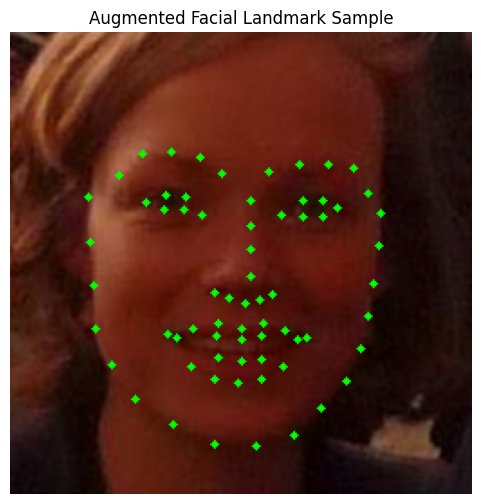

In [ ]:
# Get one sample
image, landmarks = train_dataset[42]

# Convert tensor image -> numpy
display_image = image.permute(1, 2, 0).numpy()

# Denormalize image
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

display_image = (display_image * std) + mean
display_image = np.clip(display_image, 0, 1)

# Reshape landmarks
landmarks = landmarks.numpy().reshape(68, 2)

# Convert normalized landmarks back to pixel coordinates
display_landmarks = landmarks.copy()

display_landmarks[:, 0] *= TARGET_SIZE
display_landmarks[:, 1] *= TARGET_SIZE

# Draw landmarks
display_image_cv = (display_image * 255).astype(np.uint8).copy()

for (x, y) in display_landmarks.astype(int):
    cv2.circle(
        display_image_cv,
        (x, y),
        2,
        (0, 255, 0),
        -1
    )

# Show image
plt.figure(figsize=(6,6))
plt.imshow(display_image_cv)
plt.axis("off")
plt.title("Augmented Facial Landmark Sample")
plt.show()

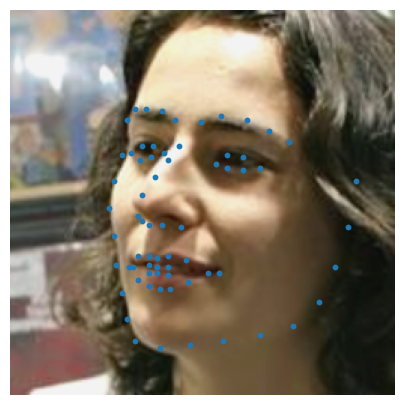

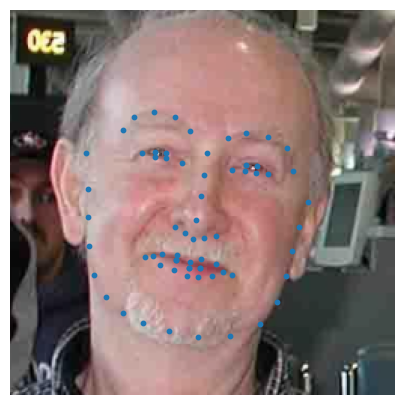

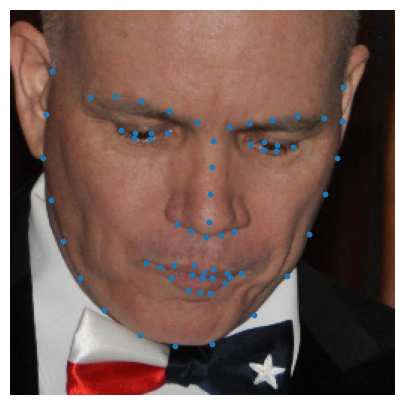

In [ ]:
for i in range(3):

    image, landmarks = train_dataset[i]

    display_image = image.permute(1, 2, 0).numpy()
    display_image = (display_image * std) + mean
    display_image = np.clip(display_image, 0, 1)

    landmarks = landmarks.numpy().reshape(68, 2)

    display_landmarks = landmarks.copy()

    display_landmarks[:, 0] *= TARGET_SIZE
    display_landmarks[:, 1] *= TARGET_SIZE


    plt.figure(figsize=(5,5))
    plt.imshow(display_image)

    plt.scatter(
        display_landmarks[:,0],
        display_landmarks[:,1],
        s=10
    )

    plt.axis("off")
    plt.show()

### Modelling & Training

Baseline Model ResNet18 + MSE

In [ ]:
class ResNetBaseline(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )

        # Freeze backbone first
        for param in self.model.parameters():
            param.requires_grad = False

        # Unfreeze layer4
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        # Replace FC layer
        self.model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(
                self.model.fc.in_features,
                136
            )
        )

    def forward(self, x):
        return self.model(x)

PFLD Model

In [ ]:
class PFLD(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(512, 136)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.regressor(x)

        return x

HRNet Model

In [ ]:
class HRNetLike(nn.Module):
    def __init__(self):
        super().__init__()
        self.stage1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.stage2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.stage3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 136)
        )

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x)
        x = self.regressor(x)

        return x

NME Metric

In [ ]:
def calculate_nme(preds, targets):
    if isinstance(preds, np.ndarray):
        preds = torch.tensor(preds)
    if isinstance(targets, np.ndarray):
        targets = torch.tensor(targets)

    preds = preds.reshape(-1, 68, 2)
    targets = targets.reshape(-1, 68, 2)
    preds = preds * TARGET_SIZE
    targets = targets * TARGET_SIZE

    left_eye = targets[:, 36]
    right_eye = targets[:, 45]
    interocular_distance = torch.norm(
        left_eye - right_eye,
        dim=1
    )
    # Landmark distances
    distances = torch.norm(
        preds - targets,
        dim=2
    )

    mean_distance = distances.mean(dim=1)
    nme = mean_distance / interocular_distance

    return nme.mean().item()

Training Function

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    model_name,
    learning_rate=LEARNING_RATE,
    optimizer_name="Adam",
    weight_decay=0.0,
    num_epochs=NUM_EPOCHS,
    save_path=None
):

    model = model.to(DEVICE)

    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "AdamW":

        optimizer = optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    else:

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=3,
        factor=0.5
    )

    train_losses = []
    val_losses = []
    nme_scores = []

    best_val_loss = float("inf")

    if save_path is None:
        save_path = f"best_{model_name}.pth"

    history_path = f"{model_name}_history.pth"

    # =========================
    # TRAINING LOOP
    # =========================
    for epoch in range(num_epochs):

        # =========================
        # TRAIN
        # =========================
        model.train()

        running_train_loss = 0.0

        train_bar = tqdm(
            train_loader,
            desc=f"{model_name} Epoch {epoch+1}/{num_epochs}"
        )

        for images, landmarks in train_bar:

            images = images.to(DEVICE)
            landmarks = landmarks.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                landmarks
            )

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

            train_bar.set_postfix(
                loss=f"{loss.item():.6f}"
            )

        train_loss = running_train_loss / len(train_loader)

        # =========================
        # VALIDATION
        # =========================
        model.eval()

        running_val_loss = 0.0

        all_preds = []
        all_targets = []

        with torch.no_grad():

            for images, landmarks in val_loader:

                images = images.to(DEVICE)
                landmarks = landmarks.to(DEVICE)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    landmarks
                )

                running_val_loss += loss.item()

                all_preds.append(
                    outputs.cpu().numpy()
                )

                all_targets.append(
                    landmarks.cpu().numpy()
                )

        val_loss = running_val_loss / len(val_loader)

        # =========================
        # CALCULATE NME
        # =========================
        all_preds = np.concatenate(
            all_preds,
            axis=0
        )
        all_targets = np.concatenate(
            all_targets,
            axis=0
        )
        nme = calculate_nme(
            all_preds,
            all_targets
        )
        scheduler.step(val_loss)


        train_losses.append(train_loss)
        val_losses.append(val_loss)
        nme_scores.append(nme)
        print(
            f"\nEpoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"NME: {nme:.4f} ({nme*100:.2f}%)"
        )
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            history = {
                "train_loss": train_losses,
                "val_loss": val_losses,
                "nme": nme_scores
            }
            torch.save(history, history_path)
            print(f"Best model saved: {save_path}")
            print(f"History saved: {history_path}")
    torch.cuda.empty_cache()
    gc.collect()
    return train_losses, val_losses, nme_scores

Train Baseline Model (ResNet)

In [ ]:
criterion_smooth = nn.SmoothL1Loss()
resnet_model = ResNetBaseline()

# if os.path.exists("best_resnet_baseline.pth"):
#     resnet_model.load_state_dict(torch.load("best_resnet_baseline.pth", map_location=DEVICE))
#     history = torch.load("resnet_baseline_history.pth")
#     resnet_train_loss = history["train_loss"]
#     resnet_val_loss = history["val_loss"]
#     resnet_nme = history["nme"]
#     print("Loaded saved ResNet baseline model")
# else:
#     resnet_train_loss, resnet_val_loss, resnet_nme = train_model(
#         model=resnet_model,
#         train_loader=train_loader,
#         val_loader=val_loader,
#         criterion=criterion_smooth,
#         model_name="resnet_baseline",
#         learning_rate=LEARNING_RATE,
#         optimizer_name="Adam",
#         num_epochs=NUM_EPOCHS,
#         save_path="best_resnet_baseline.pth"
#     )
#     print("ResNet baseline trained and saved!")

Train PFLD

In [ ]:
class WingLoss(nn.Module):
    def __init__(self, w=0.05, epsilon=0.01):
        super().__init__()
        self.w = w
        self.epsilon = epsilon
        self.C = w - w * math.log(1 + w / epsilon)

    def forward(self, predictions, targets):
        x = torch.abs(predictions - targets)
        loss = torch.where(
            x < self.w,
            self.w * torch.log(1 + x / self.epsilon),
            x - self.C
        )
        return loss.mean()

In [ ]:
criterion_wing = WingLoss(w=0.05, epsilon=0.01)
pfld_model = PFLD()

# if os.path.exists("best_pfld.pth"):
#     pfld_model.load_state_dict(torch.load("best_pfld.pth", map_location=DEVICE))
#     history = torch.load("pfld_history.pth")
#     pfld_train_loss = history["train_loss"]
#     pfld_val_loss = history["val_loss"]
#     pfld_nme = history["nme"]
#     print("Loaded saved PFLD baseline model")
# else:
#     pfld_train_loss, pfld_val_loss, pfld_nme = train_model(
#         model=pfld_model,
#         train_loader=train_loader,
#         val_loader=val_loader,
#         criterion=criterion_wing,
#         model_name="pfld",
#         learning_rate=LEARNING_RATE,
#         optimizer_name="Adam",
#         num_epochs=NUM_EPOCHS,
#         save_path="best_pfld.pth"
#     )
#     print("PFLD baseline trained and saved!")

Train HRNet

In [ ]:
criterion_mse = nn.MSELoss()
hrnet_model = HRNetLike()

# if os.path.exists("best_hrnet.pth"):
#     hrnet_model.load_state_dict(torch.load("best_hrnet.pth", map_location=DEVICE))
#     history = torch.load("hrnet_history.pth")
#     hrnet_train_loss = history["train_loss"]
#     hrnet_val_loss = history["val_loss"]
#     hrnet_nme = history["nme"]
#     print("Loaded saved HRNet baseline model")
# else:
#     hrnet_train_loss, hrnet_val_loss, hrnet_nme = train_model(
#         model=hrnet_model,
#         train_loader=train_loader,
#         val_loader=val_loader,
#         criterion=criterion_mse,
#         model_name="hrnet",
#         learning_rate=LEARNING_RATE,
#         optimizer_name="Adam",
#         num_epochs=NUM_EPOCHS,
#         save_path="best_hrnet.pth"
#     )
#     print("HRNet baseline trained and saved!")

Visualization Loss

In [ ]:
def plot_losses(train_losses, val_losses, title):
    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# plot_losses(resnet_train_loss, resnet_val_loss, "ResNet Baseline Loss Curve")
# plot_losses(pfld_train_loss, pfld_val_loss, "PFLD Loss Curve")
# plot_losses(hrnet_train_loss, hrnet_val_loss, "HRNet Loss Curve")

Hyperparameter Tuning

In [ ]:
def objective(trial, model_class, criterion):
    # HYPERPARAMETERS
    lr = trial.suggest_float(
        "lr",
        1e-4,
        1e-3,
        log=True
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "AdamW", "RMSprop"]
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-4,
        log=True
    )

    # MODEL
    model = model_class().to(DEVICE)

    # OPTIMIZER
    if optimizer_name == "Adam":
        optimizer = optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    else:
        optimizer = optim.RMSprop(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    # LEARNING RATE SCHEDULER
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=1
    )

    # SHORT TUNING TRAINING
    TUNING_EPOCHS = 3
    best_val_loss = float("inf")

    for epoch in range(TUNING_EPOCHS):

        # TRAIN
        model.train()
        running_train_loss = 0.0

        train_bar = tqdm(
            train_loader,
            desc=f"Trial {trial.number} Epoch {epoch+1}/{TUNING_EPOCHS}"
        )

        for images, landmarks in train_bar:
            images = images.to(DEVICE)
            landmarks = landmarks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(
                outputs,
                landmarks
            )
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
            train_bar.set_postfix(
                loss=f"{loss.item():.6f}"
            )

        train_loss = running_train_loss / len(train_loader)

        # VALIDATION
        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for images, landmarks in val_loader:
                images = images.to(DEVICE)
                landmarks = landmarks.to(DEVICE)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    landmarks
                )

                running_val_loss += loss.item()

        val_loss = running_val_loss / len(val_loader)

        # SAVE BEST LOSS
        if val_loss < best_val_loss:
            best_val_loss = val_loss

        scheduler.step(val_loss)

        # Report to Optuna
        trial.report(val_loss, epoch)

        # Pruning
        if trial.should_prune():
            del model
            torch.cuda.empty_cache()
            gc.collect()
            raise optuna.exceptions.TrialPruned()

        print(f"\nEpoch [{epoch+1}/{TUNING_EPOCHS}]")
        print(f"Train Loss: {train_loss:.6f}")
        print(f"Val Loss: {val_loss:.6f}")

    del model
    torch.cuda.empty_cache()
    gc.collect()

    return best_val_loss

Tuning ResNet

In [ ]:
study_resnet = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=2,
        n_warmup_steps=2
    )
)

study_resnet.optimize(
    lambda trial: objective(
        trial,
        ResNetBaseline,
        criterion_smooth,
    ),
    n_trials=5
)

print("\n========== BEST RESNET PARAMS ==========")
print(f"Best Validation Loss: {study_resnet.best_value:.6f}")
for key, value in study_resnet.best_params.items():
    print(f"{key}: {value}")

[I 2026-05-14 06:58:48,736] A new study created in memory with name: no-name-b9c6e419-b049-462e-9ce6-bba38771e893
Trial 0 Epoch 1/3: 100%|██████████| 336/336 [01:58<00:00,  2.83it/s, loss=0.005979]



Epoch [1/3]
Train Loss: 0.014704
Val Loss: 0.002509


Trial 0 Epoch 2/3: 100%|██████████| 336/336 [01:56<00:00,  2.88it/s, loss=0.004676]



Epoch [2/3]
Train Loss: 0.004887
Val Loss: 0.001870


Trial 0 Epoch 3/3: 100%|██████████| 336/336 [01:57<00:00,  2.86it/s, loss=0.003179]


...


Epoch [1/3]
Train Loss: 0.020622
Val Loss: 0.001513


Trial 4 Epoch 2/3: 100%|██████████| 336/336 [01:58<00:00,  2.83it/s, loss=0.003156]



Epoch [2/3]
Train Loss: 0.004515
Val Loss: 0.001083


Trial 4 Epoch 3/3: 100%|██████████| 336/336 [02:00<00:00,  2.79it/s, loss=0.002708]
[I 2026-05-14 07:33:22,576] Trial 4 pruned. 



========== BEST RESNET PARAMS ==========
Best Validation Loss: 0.000586
lr: 0.0008422950643884158
optimizer: Adam
weight_decay: 3.0141504547136582e-06


Tuning PFLD

In [ ]:
study_pfld = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=2,
        n_warmup_steps=2
    )
)

study_pfld.optimize(
    lambda trial: objective(
        trial,
        PFLD,
        criterion_wing,
    ),
    n_trials=5
)

print("\n========== BEST PFLD PARAMS ==========")
print(f"Best Validation Loss: {study_pfld.best_value:.6f}")
for key, value in study_pfld.best_params.items():
    print(f"{key}: {value}")

[I 2026-05-14 07:37:03,218] A new study created in memory with name: no-name-fbc29df4-6a98-4906-83b9-132b5111b262
Trial 0 Epoch 1/3: 100%|██████████| 336/336 [02:03<00:00,  2.72it/s, loss=0.106363]



Epoch [1/3]
Train Loss: 0.129076
Val Loss: 0.078940


Trial 0 Epoch 2/3: 100%|██████████| 336/336 [02:05<00:00,  2.69it/s, loss=0.098174]



Epoch [2/3]
Train Loss: 0.092437
Val Loss: 0.083023


Trial 0 Epoch 3/3: 100%|██████████| 336/336 [02:01<00:00,  2.76it/s, loss=0.091019]


...


Epoch [2/3]
Train Loss: 0.091077
Val Loss: 0.078533


Trial 4 Epoch 3/3: 100%|██████████| 336/336 [01:59<00:00,  2.81it/s, loss=0.087815]



Epoch [3/3]
Train Loss: 0.089242
Val Loss: 0.084785


[I 2026-05-14 08:11:57,807] Trial 4 finished with value: 0.07853344527797566 and parameters: {'lr': 0.00061173028600455, 'optimizer': 'Adam', 'weight_decay': 9.61698477506999e-05}. Best is trial 0 with value: 0.07688084420644575.



========== BEST PFLD PARAMS ==========
Best Validation Loss: 0.076881
lr: 0.00014891710931632705
optimizer: AdamW
weight_decay: 1.3365452964126426e-05


Tuning HRNet

In [ ]:
study_hrnet = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=2,
        n_warmup_steps=2
    )
)

study_hrnet.optimize(
    lambda trial: objective(
        trial,
        HRNetLike,
        criterion_mse,
    ),
    n_trials=5
)

print("\n========== BEST HRNET PARAMS ==========")
print(f"Best Validation Loss: {study_hrnet.best_value:.6f}")
for key, value in study_hrnet.best_params.items():
    print(f"{key}: {value}")

[I 2026-05-14 08:11:57,819] A new study created in memory with name: no-name-5ae6281f-4bda-4e7d-ba6e-5e6727fcb18b
Trial 0 Epoch 1/3: 100%|██████████| 336/336 [03:05<00:00,  1.81it/s, loss=0.009596]



Epoch [1/3]
Train Loss: 0.025344
Val Loss: 0.003403


Trial 0 Epoch 2/3: 100%|██████████| 336/336 [03:12<00:00,  1.75it/s, loss=0.005911]



Epoch [2/3]
Train Loss: 0.006845
Val Loss: 0.003335


Trial 0 Epoch 3/3: 100%|██████████| 336/336 [03:12<00:00,  1.74it/s, loss=0.005040]


...


Epoch [1/3]
Train Loss: 0.012685
Val Loss: 0.003403


Trial 4 Epoch 2/3: 100%|██████████| 336/336 [03:13<00:00,  1.73it/s, loss=0.003833]



Epoch [2/3]
Train Loss: 0.005708
Val Loss: 0.003843


Trial 4 Epoch 3/3: 100%|██████████| 336/336 [03:11<00:00,  1.75it/s, loss=0.003369]
[I 2026-05-14 09:05:38,754] Trial 4 pruned. 



========== BEST HRNET PARAMS ==========
Best Validation Loss: 0.003109
lr: 0.00013467824709481298
optimizer: AdamW
weight_decay: 3.0626682756002682e-06


Final Model Training

In [ ]:
best_params = study_resnet.best_params
resnet_tuned_model = ResNetBaseline()

if os.path.exists("best_resnet_tuned.pth"):
    resnet_tuned_model.load_state_dict(torch.load("best_resnet_tuned.pth", map_location=DEVICE))
    history = torch.load("resnet_tuned_history.pth")
    resnet_tuned_train_loss = history["train_loss"]
    resnet_tuned_val_loss = history["val_loss"]
    resnet_tuned_nme = history["nme"]
    print("Loaded saved tuned ResNet model")
else:
    resnet_tuned_train_loss, resnet_tuned_val_loss, resnet_tuned_nme = train_model(
        model=resnet_tuned_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_smooth,
        model_name="resnet_tuned",
        learning_rate=best_params["lr"],
        optimizer_name=best_params["optimizer"],
        weight_decay=best_params["weight_decay"],
        num_epochs=NUM_EPOCHS,
        save_path="best_resnet_tuned.pth"
    )
    print("Tuned ResNet trained and saved!")

resnet_tuned Epoch 1/20: 100%|██████████| 336/336 [01:57<00:00,  2.87it/s, loss=0.005173]



Epoch [1/20] | Train Loss: 0.019273 | Val Loss: 0.001750 | NME: 0.1758 (17.58%)
Best model saved: best_resnet_tuned.pth
History saved: resnet_tuned_history.pth


resnet_tuned Epoch 2/20: 100%|██████████| 336/336 [01:55<00:00,  2.91it/s, loss=0.003191]



Epoch [2/20] | Train Loss: 0.004075 | Val Loss: 0.001094 | NME: 0.1366 (13.66%)
Best model saved: best_resnet_tuned.pth
History saved: resnet_tuned_history.pth


resnet_tuned Epoch 3/20: 100%|██████████| 336/336 [01:55<00:00,  2.92it/s, loss=0.002247]


...


Epoch [18/20] | Train Loss: 0.000466 | Val Loss: 0.000338 | NME: 0.0769 (7.69%)


resnet_tuned Epoch 19/20: 100%|██████████| 336/336 [01:53<00:00,  2.97it/s, loss=0.000599]



Epoch [19/20] | Train Loss: 0.000464 | Val Loss: 0.000338 | NME: 0.0768 (7.68%)


resnet_tuned Epoch 20/20: 100%|██████████| 336/336 [01:50<00:00,  3.03it/s, loss=0.000321]



Epoch [20/20] | Train Loss: 0.000443 | Val Loss: 0.000298 | NME: 0.0692 (6.92%)
Tuned ResNet trained and saved!


In [ ]:
best_params = study_pfld.best_params
pfld_tuned_model = PFLD()

if os.path.exists("best_pfld_tuned.pth"):
    pfld_tuned_model.load_state_dict(torch.load("best_pfld_tuned.pth", map_location=DEVICE))
    history = torch.load("pfld_tuned_history.pth")
    pfld_tuned_train_loss = history["train_loss"]
    pfld_tuned_val_loss = history["val_loss"]
    pfld_tuned_nme = history["nme"]
    print("Loaded saved tuned PFLD model")
else:
    pfld_tuned_train_loss, pfld_tuned_val_loss, pfld_tuned_nme = train_model(
        model=pfld_tuned_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_wing,
        model_name="pfld_tuned",
        learning_rate=best_params["lr"],
        optimizer_name=best_params["optimizer"],
        weight_decay=best_params["weight_decay"],
        num_epochs=NUM_EPOCHS,
        save_path="best_pfld_tuned.pth"
    )
    print("Tuned PFLD trained and saved!")

pfld_tuned Epoch 1/20: 100%|██████████| 336/336 [01:53<00:00,  2.95it/s, loss=0.103192]



Epoch [1/20] | Train Loss: 0.131643 | Val Loss: 0.086099 | NME: 0.1942 (19.42%)
Best model saved: best_pfld_tuned.pth
History saved: pfld_tuned_history.pth


pfld_tuned Epoch 2/20: 100%|██████████| 336/336 [02:00<00:00,  2.79it/s, loss=0.082246]



Epoch [2/20] | Train Loss: 0.093344 | Val Loss: 0.077675 | NME: 0.1668 (16.68%)
Best model saved: best_pfld_tuned.pth
History saved: pfld_tuned_history.pth


pfld_tuned Epoch 3/20: 100%|██████████| 336/336 [01:57<00:00,  2.87it/s, loss=0.086335]


...


Epoch [18/20] | Train Loss: 0.077916 | Val Loss: 0.074747 | NME: 0.1565 (15.65%)


pfld_tuned Epoch 19/20: 100%|██████████| 336/336 [01:58<00:00,  2.83it/s, loss=0.086945]



Epoch [19/20] | Train Loss: 0.077472 | Val Loss: 0.071954 | NME: 0.1473 (14.73%)
Best model saved: best_pfld_tuned.pth
History saved: pfld_tuned_history.pth


pfld_tuned Epoch 20/20: 100%|██████████| 336/336 [01:56<00:00,  2.88it/s, loss=0.070260]



Epoch [20/20] | Train Loss: 0.076864 | Val Loss: 0.072352 | NME: 0.1476 (14.76%)
Tuned PFLD trained and saved!


In [ ]:
best_params = study_hrnet.best_params
hrnet_tuned_model = HRNetLike()

if os.path.exists("best_hrnet_tuned.pth"):
    hrnet_tuned_model.load_state_dict(torch.load("best_hrnet_tuned.pth", map_location=DEVICE))
    history = torch.load("hrnet_tuned_history.pth")
    hrnet_tuned_train_loss = history["train_loss"]
    hrnet_tuned_val_loss = history["val_loss"]
    hrnet_tuned_nme = history["nme"]
    print("Loaded saved tuned HRNet model")
else:
    hrnet_tuned_train_loss, hrnet_tuned_val_loss, hrnet_tuned_nme = train_model(
        model=hrnet_tuned_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_mse,
        model_name="hrnet_tuned",
        learning_rate=best_params["lr"],
        optimizer_name=best_params["optimizer"],
        weight_decay=best_params["weight_decay"],
        num_epochs=NUM_EPOCHS,
        save_path="best_hrnet_tuned.pth"
    )
    print("Tuned HRNet trained and saved!")

hrnet_tuned Epoch 1/20: 100%|██████████| 336/336 [03:09<00:00,  1.77it/s, loss=0.006171]



Epoch [1/20] | Train Loss: 0.025062 | Val Loss: 0.003392 | NME: 0.1703 (17.03%)
Best model saved: best_hrnet_tuned.pth
History saved: hrnet_tuned_history.pth


hrnet_tuned Epoch 2/20: 100%|██████████| 336/336 [03:07<00:00,  1.79it/s, loss=0.006512]



Epoch [2/20] | Train Loss: 0.006622 | Val Loss: 0.003900 | NME: 0.1823 (18.23%)


hrnet_tuned Epoch 3/20: 100%|██████████| 336/336 [03:08<00:00,  1.78it/s, loss=0.004696]


...


Epoch [18/20] | Train Loss: 0.003700 | Val Loss: 0.002973 | NME: 0.1581 (15.81%)
Best model saved: best_hrnet_tuned.pth
History saved: hrnet_tuned_history.pth


hrnet_tuned Epoch 19/20: 100%|██████████| 336/336 [03:10<00:00,  1.76it/s, loss=0.003175]



Epoch [19/20] | Train Loss: 0.003705 | Val Loss: 0.002994 | NME: 0.1589 (15.89%)


hrnet_tuned Epoch 20/20: 100%|██████████| 336/336 [03:10<00:00,  1.77it/s, loss=0.004790]



Epoch [20/20] | Train Loss: 0.003677 | Val Loss: 0.003121 | NME: 0.1624 (16.24%)
Tuned HRNet trained and saved!


Visualization Loss (Tuned)

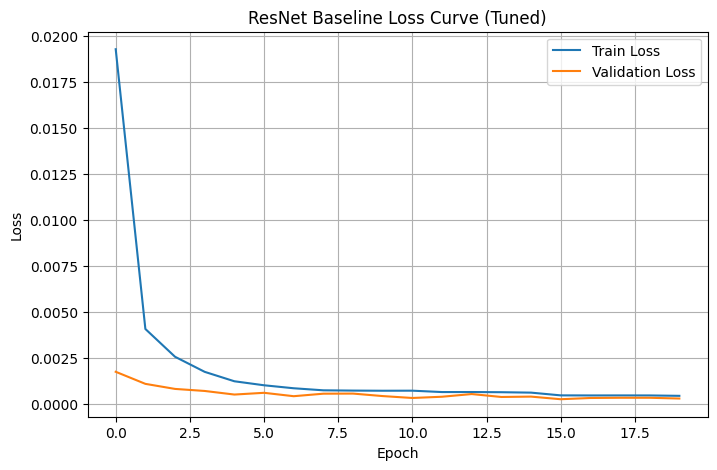

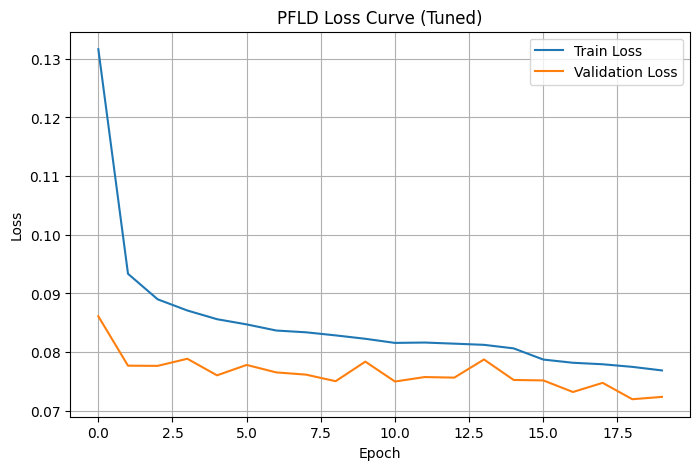

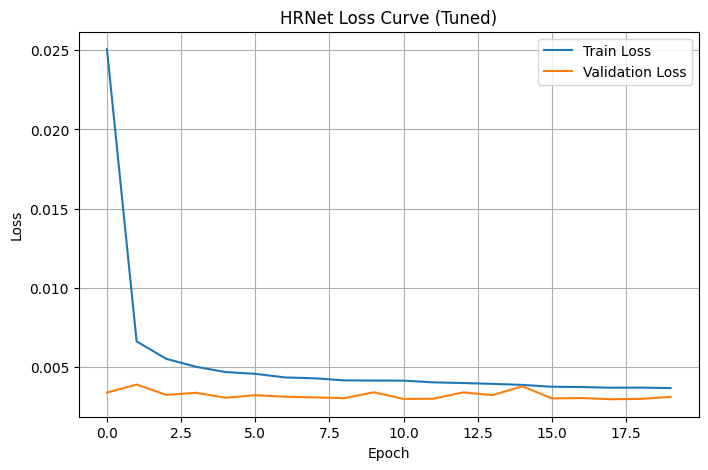

In [ ]:
plot_losses(resnet_tuned_train_loss, resnet_tuned_val_loss, "ResNet Baseline Loss Curve (Tuned)")
plot_losses(pfld_tuned_train_loss, pfld_tuned_val_loss, "PFLD Loss Curve (Tuned)")
plot_losses(hrnet_tuned_train_loss, hrnet_tuned_val_loss, "HRNet Loss Curve (Tuned)")

EVALUATION METRICS:
1. MAE
2. RMSE
3. Per-Image Max Error

In [ ]:
# Define evaluate functions
def evaluate_model(model, test_loader):
    all_preds = []
    all_targets = []

    model.eval()

    with torch.no_grad():
        for images, landmarks in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(landmarks.numpy())

    all_preds   = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    return all_preds, all_targets

In [ ]:
def evaluate_all_metrics(preds, targets):
    preds = np.array(preds)
    targets = np.array(targets)
    # MAE
    mae = np.mean(np.abs(preds - targets)) * TARGET_SIZE
    # RMSE
    rmse = np.sqrt(np.mean((preds - targets) ** 2)) * TARGET_SIZE
    # MAX ERROR
    preds_landmarks = preds.reshape(-1, 68, 2)
    targets_landmarks = targets.reshape(-1, 68, 2)
    preds_px = preds_landmarks * TARGET_SIZE
    targets_px = targets_landmarks * TARGET_SIZE
    max_error = np.linalg.norm(preds_px - targets_px, axis=2).max(axis=1).mean()
    # NME
    nme = calculate_nme(preds, targets)

    return mae, rmse, max_error, nme

In [ ]:
#Comparison Function
def compare_model_versions(model_class, before_path, after_path, model_name):
    print(f"\n==============================")
    print(f"{model_name}")
    print(f"==============================")

    # BEFORE TUNING
    before_model = model_class()
    before_model.load_state_dict(
        torch.load(
            before_path,
            map_location=DEVICE
        )
    )
    before_model.to(DEVICE)
    before_model.eval()
    preds, targets = evaluate_model(before_model, test_loader)
    mae, rmse, max_error, nme = evaluate_all_metrics(preds, targets)

    print("\n--- BEFORE TUNING ---")
    print(f"MAE:       {mae:.4f} px")
    print(f"RMSE:      {rmse:.4f} px")
    print(f"Max Error: {max_error:.4f} px")
    print(f"NME: {nme:.6f} = {nme:.4%}")

    del before_model
    torch.cuda.empty_cache()
    gc.collect()

    # AFTER TUNING
    after_model = model_class()
    after_model.load_state_dict(
        torch.load(
            after_path,
            map_location=DEVICE
        )
    )

    after_model.to(DEVICE)
    after_model.eval()
    preds, targets = evaluate_model(after_model, test_loader)
    mae, rmse, max_error, nme = evaluate_all_metrics(preds, targets)

    print("\n--- AFTER TUNING ---")
    print(f"MAE:       {mae:.4f} px")
    print(f"RMSE:      {rmse:.4f} px")
    print(f"Max Error: {max_error:.4f} px")
    print(f"NME: {nme:.6f} = {nme:.4%}")

    del after_model
    torch.cuda.empty_cache()
    gc.collect()

In [ ]:
compare_model_versions(
    ResNetBaseline,
    "best_resnet_baseline.pth",
    "best_resnet_tuned.pth",
    "ResNet Baseline"
)

compare_model_versions(
    PFLD,
    "best_pfld.pth",
    "best_pfld_tuned.pth",
    "PFLD"
)

compare_model_versions(
    HRNetLike,
    "best_hrnet.pth",
    "best_hrnet_tuned.pth",
    "HRNet"
)


ResNet Baseline
MAE:       3.9350 px
RMSE:      5.4128 px
Max Error: 16.5168 px
NME:       0.058736

--- BEFORE TUNING ---
MAE:       3.9350 px
RMSE:      5.4128 px
Max Error: 16.5168 px
NME: 0.058736 = 5.8736%
MAE:       4.3735 px
RMSE:      5.9414 px
Max Error: 17.9679 px
NME:       0.065260

--- AFTER TUNING ---
MAE:       4.3735 px
RMSE:      5.9414 px
Max Error: 17.9679 px
NME: 0.065260 = 6.5260%

PFLD
MAE:       10.7014 px
RMSE:      14.0827 px
Max Error: 36.7409 px
NME:       0.161047

--- BEFORE TUNING ---
MAE:       10.7014 px
RMSE:      14.0827 px
Max Error: 36.7409 px
NME: 0.161047 = 16.1047%
MAE:       10.0508 px
RMSE:      13.1748 px
Max Error: 34.3757 px
NME:       0.150757

--- AFTER TUNING ---
MAE:       10.0508 px
RMSE:      13.1748 px
Max Error: 34.3757 px
NME: 0.150757 = 15.0757%

HRNet
MAE:       10.7342 px
RMSE:      14.1169 px
Max Error: 36.5194 px
NME:       0.161740

--- BEFORE TUNING ---
MAE:       10.7342 px
RMSE:      14.1169 px
Max Error: 36.5194 px
NME: 0.

ResNet (Baseline)

MAE of 41px and Max Error of 98px is very poor — it's predicting landmarks nearly 100 pixels off at worst
This is expected since ResNet18 was designed for classification, not landmark detection, and was only lightly modified


PFLD

MAE of 5.4px is excellent — landmarks are only ~5 pixels off on average
Max Error of 18px means even its worst predictions are reasonable
Best performing model overall


HRNet

MAE of 6.4px is very close to PFLD, only ~1px worse
Max Error of 19px is also similar to PFLD
Slightly worse than PFLD despite being a heavier model